Authors:

- Michiel Rollier
- João Vitor Merenda
- Lucas Caldeira de Oliveira

In [7]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

In [8]:
from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *

# 0 - Table of Symbols

Note: I think it's better to follow the notational convention used by Milan, Vichniac, Bagnoli, etc.

Note: the notation related to the Lyapunov spectrum is optimal in the Notebook 'lyapunov-sanity-check.ipynb'.

- $G = (V,E)$: a simple graph defined based on its nodes and edges
- $V = \{v\}$: set of nodes;
- $E = \{(v_i,v_j)\}$: set of unweighted edges;
- $\mathbf{A} = [a_{i,j}] \in \{0;1\}^{|V| \times |V|}$: binary adjacency matrix where $a_{i,j} = 1$ denotes the existence of the edge $(v_i,v_j)$;
- $\mathcal{N}(v_i) = \{v_j~|~\forall j : a_{i,j} \neq 0 \}$: the neighbourhood of node $v_i$.
- $\mathcal{C} = \langle \mathcal{T}, \mathbb{S}, \vec{s}_0, \Phi \rangle$: automaton defined on a tesselation $\mathcal{T}$, a set of discrete states $\mathbb{S}$, an initial configuration $\vec{s}_0$ and a transition function $\Phi$;
- $\vec{s}_t = [s_{i,t}] \in \mathbb{S}^{|V|}$: state vector of $i$-th nodes at time step $t$;
- $\vec{s}^*_t = \vec{s}_t \oplus \delta\vec{s}$: distubed state vector at time step $t$ by the module-$|\mathbb{S}|$ addition with a perturbation vector;
- $\mathbf{H} = [\vec{s}_t] \in \mathbb{S}^{|V| \times T}$ state matrix of nodes evolved by $T$ steps (i.e. time evolution patterns);

# 1 - Introduction

## 1.1 - Cellular Automata, graph theory and network automata

### _1.1.x - Life-like network automata with resolution R_

The Game of Life is defined in a two-dimensional regular grid where every cell has a Moore neighbourhood (8+1 neighbours), and (copied from Zielinski et al. 2022)
- Any live cell with fewer than two life neighbours will die of loneliness,
- Any live cell with more than three live neighbours will die of over-crowding,
- Any live cell with two or three live neighbours will survive,
- Any dead cell with three live neighbours will be born

This can be generalised to a network, but the issue now is that there is no fixed number of neighbours. If we want to formulate a uniform rule, we will therefore have to define it in terms of densities (fraction of neighbours), rather than the absolute number of neighbours:
$$
\rho(v_i,t) = \frac{1}{|\mathcal{N}(v_i)|}\sum_{v_j \in \mathcal{N}(v_i)} s_{j,t},
$$
such that $0 \leq \rho(v_i,t) \leq 1$.

Now we can define a general Life-like network automaton (LLNA) rule, by indicating:
- When the node is dead, for what neighbourhood densities should it be born?
- When the node is alive, for what neighbourhood densitities should it survive?

Because the density parameter can be any value from $0$ to $1$, there is an infinite number of possible LLNA rules. In order to impose a meaningful structure in this infinite possiblities, we discretise the density domain into a number of subdomains (this number is called the "resolution"). We associate each of these subdomains with a particular binary outcome (alive or dead).

As an example, consider the resolution $R=4$. This allows for $4^2 \times 4^2 = 256$ possible LLNA rules. If each of the density domains is associated with death, we simply write this as rule `R=4:B_S`. If each of the density domains is associated with life, we write `R=4:B0123_S0123`. Below is a visualisation of rule `R=4:B01_S03`.

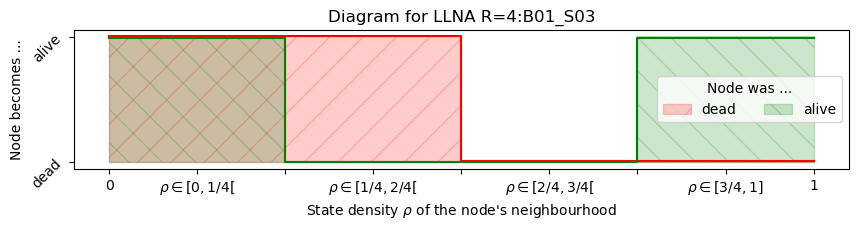

In [9]:
LLNA_rule = "R=4:B01_S03"
resolution = 4
born_if = [0,1]
survive_if = [0,3]

subdoms = []; born = []; survive = []
for i in range(resolution):
    subdoms += [i, i+1]
    if i in born_if:
        born += [1, 1]
    else:
        born += [0, 0]
    if i in survive_if:
        survive += [1, 1]
    else:
        survive += [0, 0]
subdoms = np.array(subdoms) / resolution

fig, ax = plt.subplots(1,1,figsize=(10,1.8))
offset = 0.005

born = np.array(born)
survive = np.array(survive)
# colors
born_color = 'red'
survive_color = 'green'
# top curves
ax.plot(subdoms, born+offset, color=born_color)
ax.plot(subdoms, survive-offset, color=survive_color)
# hatches
ax.fill_between(subdoms, 0, born+offset, facecolor=born_color, alpha=.2, hatch='/', edgecolor=born_color, label='dead')
ax.fill_between(subdoms, 0, survive+offset, facecolor=survive_color, alpha=.2, hatch='\\', edgecolor=survive_color, label='alive')

# add markers for discontinuous points
# ax.scatter(subdoms[1], born[1], s=50, color='green')
# ax.scatter(subdoms[1], survive[1], s=50, color='red')

xticks = np.arange(resolution*2+1)/(resolution*2)
xticklabels = [None]*len(xticks)
xticklabels[0] = 0; xticklabels[-1] = 1
xticklabels[1] = "$\\rho \in [0, 1/4[$"; xticklabels[3] = "$\\rho \in [1/4,2/4[$"; xticklabels[5] = "$\\rho \in [2/4, 3/4[$"; xticklabels[7] = "$\\rho \in [3/4, 1]$"

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

yticks = [0,1]
yticklabels = ["dead", "alive"]

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, rotation=45)

ax.set_ylabel("Node becomes ...")
ax.set_xlabel(f"State density $\\rho$ of the node's neighbourhood")

ax.legend(title='Node was ...', ncol=2, loc='right')
_=ax.set_title(f"Diagram for LLNA {LLNA_rule}")

**NOTE**: the left border of each domain is included, and the right border is not, except for the final domain, where both borders are included. So for the example above, a live cell with a concentration of exactly $1/4$ would die.

We will first work with a resolution of 2, such that there are only $2^2 \times 2^2 = 16$ possible LLNA rule. This will most probably limit the dynamical richness of the system. Yet, considering the large number of other (network) variations, this is a good first step.

## 1.2 - Definition, interpretation and relevance of robustness

In [10]:
import numpy as np
import networkx as nx
import torch as tc
import torch_geometric as tg
import sys
from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *

Let $G(V,E)$ denote a network with $N$ nodes (or cells), $V = \vec{x} = \{x_1, x_2, x_3, \cdots , x_N\}$ and $|E|$ edges. Let $\mathbb{S} = \{0,1\}$ denote the set of all possible states of a cell. Thus, the configuration space of the network is $\mathbb{S}^N$. Consider $\Omega (x_i)$ as the neighborhood set of the node $x_i$. The transition function, denoted by $\Phi : \mathbb{S}^{|\Omega |} \rightarrow \mathbb{S}$, specifies that the state transition of node $x_i$ is influenced by its neighborhood. This transition function $\Phi$ establishes a global mapping $\textbf{S}: \mathbb{S}^N \rightarrow \mathbb{S}^N$, where $s_i(x_i, t) = \Phi (\Omega (x_i))$, and $\textbf{S} = (s_1, s_2, \cdots , s_N)$ is the vector state. We can denote the initial vector state as $\textbf{S}^0 = (s_1(x_i, 0), s_2(x_2, 0), \cdots , s_N(x_N, 0))$ and the vector state at step t as $\textbf{S}^t = (s_1(x_i, t), s_2(x_2, t), \cdots , s_N(x_N, t))$.

**Boolean derivatives and the Jacobian**

Given the definitions above, we can define the Boolean derivative.

$$
    \frac{\partial s_i}{\partial x_j} = \begin{cases}
s_i(x_1, x_2, \cdots , x_j \oplus 1, \cdots , x_N) \oplus s_i(x_1, x_2, \cdots , x_N)
 & \text{if a changing in } x_j \text{ causes a transition in } s_i \text{ at step } t+1\\
0 & \text{otherwise }
\end{cases}
$$
where $\oplus$ is the XOR operator (module-2 summation) (Baetens and De Baets 2011). The Boolean derivative will be $1$ if and only if a changing in the $x_j$ state at time $t$  (i.e. $s^t_j$) can induces a transition in the state of $x_i$ at time $t + 1$ (i.e. changing in $s^{t+1}_i$).

Let $\textbf{s}^0$ be the initial state of all cells and $\textbf{s}^t$ the state at time $t$, then the Jacobian is defined by:

$$
J(\vec{x}^t, t) = \begin{bmatrix}
\frac{\partial s_1(x_i,t+1) }{\partial x_1}|_t & \frac{\partial s_1(x_1,t+1)}{\partial x_2}|_t & \cdots & \frac{\partial s_1(x_1,t+1)}{\partial s_N}|_t \\[10pt]
\frac{\partial s_2(x_2,t+1)}{\partial x_1}|_t & \frac{\partial s_2(x_2,t+1)}{\partial x_2}|_t & \cdots & \frac{\partial s_2(x_2,t+1)}{\partial x_N}|_t  \\
\vdots & \vdots &  & \vdots \\
\frac{\partial s_N(x_N,t+1)}{\partial x_1}|_t & \frac{\partial s_N(x_N,t+1)}{\partial x_2}|_t & \cdots & \frac{\partial s_N(x_N, t+1)}{\partial x_N}|_t \\[10pt]
\end{bmatrix}
$$

The Jacobian describes how $n$ mutually orthogonal perturbation propagate from the time $t$ to time $t+1$.

**Configuration space**

The configuration space represents all nodes and their respective states within a network. In the context of a network, this space is represented as $\mathbb{S}^N$, constituting an N-dimensional domain.

Consider $\vec{x}^0$ as the initial configuration. A perturbation, or defect, denoted by $\delta \vec{x}^0$, induces a deviation in the trajectory within the configuration space over a time period $T$. Let $\Delta \vec{x}^0$ the difference pattern between the original trajectory on configuration space and the disturbed trajectory at step zero. This value can be measured by:

$$
       \Delta \vec{x}^0 = \textbf{S}^0(\vec{x}^0) \oplus \textbf{S}^0(\vec{x}^0 \oplus \delta\vec{x}^0)
$$

Therefore, $\Delta \vec{x}^0$  measures the displacement of the trajectories caused by a perturbation at the initial time. We can investigate whether such perturbations lead to convergence or divergence in the trajectories within the configuration space evolving them by the Jacobian.

$$
    \Delta \vec{x}^{t+1} = J(\vec{x}^t, t) \otimes \Delta \vec{x}^t
$$

Equation 4 operates recursively, meaning that to determine the difference pattern at time $t + 1$, we first calculate the difference pattern at time $t$. In turn, computing the difference pattern at time $t$ requires considering the difference pattern at time $t - 1$, and so forth. Here, the operator $\otimes$ denotes standard matrix multiplication, with the addition operation substituted by $\oplus$.

**NOTE** This is not true! One cannot calculate the difference at time step $t$ by means of this recursive relation, because the Jacobian only works for linear approximations (when only one dimension in the neighbourhood is slightly perturbed).

Convergence of $\Delta \vec{x}^{t+1}$ means stability, while exponential divergence suggests chaotic behavior.

**Lyapunov exponent on configuration space formalism**

In the configuration space, the Lyapunov exponent quantifies the rate of growth of the difference pattern between the original trajectory and the perturbed trajectory. The Lyapunov exponent, as introduced in \cite{luque2000lyapunov}, is defined as follows:

$$
    \lambda (T) = \frac{1}{T}\sum_{t = 0}^T\log\left|\frac{\Delta \vec{s}^{t+1}}{\Delta \vec{s}^t}\right|
$$

where $|\Delta \vec{s}^{t+1}| = \sum_{i=1}^N\Delta s_i^{t+1}$.

In [ ]:
#Configuration space
def conf_space(G, model, s0, s0_defect, T):
    #Delta x0 calculation:
    N = len(s0)
    edges = G.get_edgelist()
    D0 = np.mod(s0 ^ s0_defect, 2)  #initial difference between the two configurations
    D = D0 #initializing at t = 0
    states_original = np.tile(s0, (T,1)) # all states (will be updated in the loop)
    Js = np.zeros(shape=(T-1,N,N)) #Allocate space for Jacobian
    for t in range(1,T):
        states_original[t] = np.array(model.step(tc.tensor(edges).T, tc.tensor(states_original[t-1])))
        Js[t-1] = jacobian(G, model, states_original[t])
        #Delta x^t = Js * Delta x^t-1
        D = np.mod(np.matmul(Js[t-1], D),2)
    #Here, the Lyapunov exponent
    L = np.log(sum(D)/sum(D0))/T
    return L

**Tangent Space**

The tangent space of a CA is a conceptual space that allows for the analysis of how small perturbations or defects evolve in the system. It is analogous to the tangent space in continuous-state dynamical systems, where it represents the space of all possible directions in which perturbations can grow or shrink. This space is essentially a vectorial space, delineated by the tangent vector at a point $P \in \mathbb{S}^N$, and it exhibits an isomorphism with the space $\mathbb{S}^N$. The advantage of working with perturbations in tangent space is that we only need to keep track of the evolution of $n$ mutually orthogonal perturbations.

The tangent space has the linearity property, it means that we can decompose the perturbation vector into a complete and orthogonal set of vectors representing the perturbation in each direction: $\delta \vec{x}^t = \sum_{i=1}^N\delta x_i^t\vec{e}_i$, where $\{\vec{e}_i\}$ denotes the standard basis. These components evolve in accordance with the Jacobian:

$$
\begin{bmatrix}
    \delta x_1^{t+1} \\[10pt]
    \delta x_2^{t+1} \\
    \vdots \\[10pt]
    \delta x_N^{t+1} \\[10pt]
\end{bmatrix}
 = \begin{bmatrix}
\frac{\partial s_1}{\partial x_1}|_t & \frac{\partial s_1}{\partial x_2}|_t & \cdots & \frac{\partial s_1}{\partial x_N}|_t \\[10pt]
\frac{\partial s_2}{\partial x_1}|_t & \frac{\partial s_2}{\partial x_2}|_t & \cdots & \frac{\partial s_2}{\partial x_N}|_t  \\
\vdots & \vdots &  & \vdots \\
\frac{\partial s_N}{\partial x_1}|_t & \frac{\partial s_N}{\partial x_2}|_t & \cdots & \frac{\partial s_N}{\partial x_N}|_t \\[10pt]
\end{bmatrix}
\begin{bmatrix}
    \delta x_1^{t} \\[10pt]
    \delta x_2^{t} \\
    \vdots \\[10pt]
    \delta x_N^{t} \\[10pt]
    \end{bmatrix}
    \Leftrightarrow \delta \vec{x}^{t+1} = J(\vec{x}^t, t)\delta\vec{x}^t
$$

The Lyapunov exponent is defined by $\lim_{t \rightarrow \infty} \frac{1}{t}\log|\delta\vec{x}^t|$



In [ ]:
#Tangent space
def tangent_space(G, model, s0, s0_defect, T):
    #Allocating space
    N = len(s0)
    edges = G.get_edgelist()
    Js = np.zeros(shape=(T-1,N,N))
    states_original = np.tile(s0, (T,1))
    states_perturbed = np.tile(s0_defect, (T,1))
    deltas = np.tile(s0_defect, (T,1))
    for t in range(1,T):
        states_original[t] = np.array(model.step(tc.tensor(edges).T, tc.tensor(states_original[t-1])))
        states_perturbed[t] = np.array(model.step(tc.tensor(edges).T, tc.tensor(states_perturbed[t-1])))
        Js[t-1] = jacobian(G, model, states_original[t])
        deltas[t] = np.mod(np.matmul(Js[t-1], deltas[t-1]),2)
    #The Lyapunov exponent
    L = np.log(sum(deltas[t]))/T
    return L

**Relationship between damage spreading and the network diameter**

Considering a initial perturbation $\delta \vec{x}^0$ upon a subset of nodes, at step $t$, the nodes affected by perturbations form a subnetwork $G_{\Delta}^t \subseteq G$. Utilizing $G_{\Delta}^t$, we can determine the rate of spread of the variation pattern, denoted by $\gamma$ to a cellular automaton model on the network in the following manner:

$$
    \gamma (t) = \frac{1}{t}D(G^t_{\Delta})
$$
where $D(G^t_{\Delta})$ represents the diameter of the subnetwork affected by the spreading of perturbations.

**Interpretation of both formalisms**

In configuration space, the Lyapunov exponent indicates how quickly small initial differences between two states will grow. A positive Lyapunov exponent suggests that small perturbations will lead to significant divergence over time, indicating chaotic behavior. Conversely, a negative exponent implies that perturbations will die out, leading to stable behavior.

In tangent space, the Lyapunov exponent provides a more detailed picture of the system's stability by quantifying the exponential rates at which small perturbations in various directions grow or shrink. This approach offers a finer resolution of the system's dynamics, capturing the behavior of individual perturbations and their interactions over time. The spectrum of Lyapunov exponents from tangent space analysis can reveal the presence of chaotic dynamics even if the configuration space does not exhibit exponential growth directly.

In summary, while both spaces offer insights into the stability and dynamics of CA, the configuration space gives a more global view of the system's behavior under perturbations, and the tangent space provides a detailed, linearized analysis of how these perturbations evolve. The Lyapunov exponents in tangent space, being derived from a linearized model, can reveal intricate details about the system's stability and chaotic nature that might not be apparent from the configuration space alone.

## 1.3 - Example of the Lyapunov exponent in a toy NA

Below we construct a very simple NA and a very simple Jacobian.

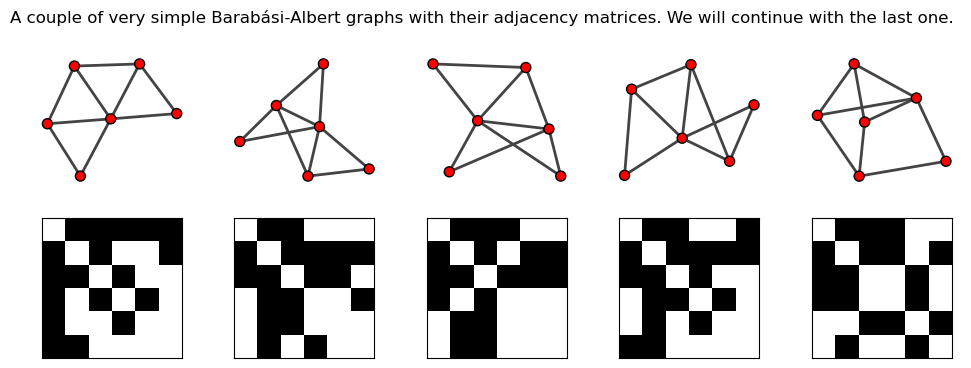

In [11]:
# a simple network
N = 6
min_edges = 2
Gs = [ig.Graph.Barabasi(N, min_edges) for _ in range(5)]

vertex_size=10
fig, axs = plt.subplots(2,5,figsize=(12,4))
for G, ax_top, ax_bottom in zip(Gs, axs[0], axs[1]):
    ig.plot(G, target=ax_top, vertex_size=vertex_size)
    A = np.array([ *G.get_adjacency() ])
    ax_bottom.imshow(A, cmap='Greys')
    ax_bottom.set_xticks([])#range(N))
    ax_bottom.set_yticks([])#range(N))
    ax_bottom.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

G = Gs[-1]
G.to_directed()
edges = G.get_edgelist()
G.to_undirected()

_=fig.suptitle("A couple of very simple Barabási-Albert graphs with their adjacency matrices. We will continue with the last one.")

Note that in this example, none of the nodes are connected to themselves. **QUESTION** is this OK? I guess it is, because the LLNA rule definitions involve the current state of the node (cf. the double curve).

In [12]:
def step_inspector(matrices:dict):
    for name in ['h', 'p', 'b', 's']:
        M = np.array(matrices[name]).round(decimals=2)
        print(f'{name}:', M.shape, M)
    print('-'*40)

def plot_params(graph, labels=False):
    import math
    params = {
        'vertex_color': np.array(graph.vs["states"])*255,
        'edge_color': 125,
        'vertex_size': 10
    }
    if labels:
        params.update({
            'vertex_label': graph.vs["name"],
            'vertex_label_color': 'blue',
            'vertex_label_size': 10,
            'vertex_label_dist': 1.5,
            'vertex_label_angle': math.pi/4
        })
    return params

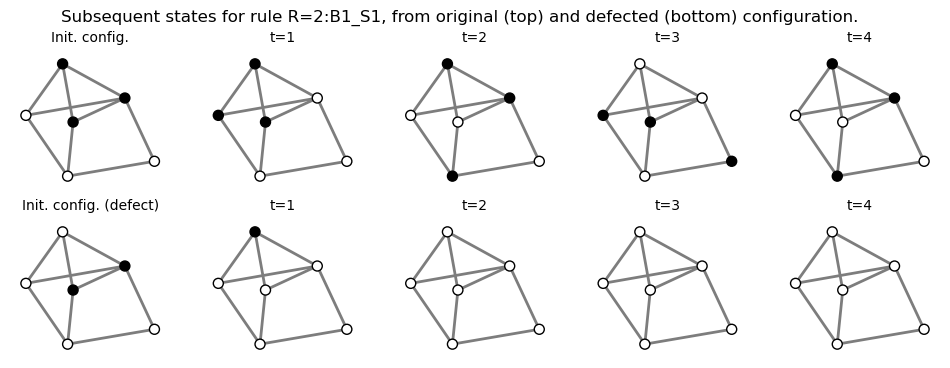

In [13]:
# a simple LLNA
resolution = 2
model = LLNA(resolution) # takes a random LLNA at this resolution
#model.rule = ([0], [0]) # specify the rule B0_S0
#model.callback = step_inspector # callback to be executed at each automaton step
rule = str(model)

# random initial condition
s0 = np.random.randint(2, size=N).astype(float)
#s0 = np.array([0,1,0,0,0,1]).astype(float) # specify the initial state
# perturbation on first node
s0_defect = s0.copy()
s0_defect[0] = 1-s0_defect[0]

# open figure
fig, axs = plt.subplots(2,5,figsize=(12,4))
size=10

G.vs["states"] = s0
G.vs["name"] = [ f'v{i}' for i in range(N) ]
ig.plot(G, target=axs[0,0], **plot_params(G, labels=False))
axs[0,0].set_title("Init. config.", size=size)

# assign to state property of graph
# turn configuration into tc tensor and add extra dimension for number of samples
st = tc.tensor(s0)[None,:]
for t, ax in enumerate(axs[0,1:]):
    # evolve over one time step
    st = model.step(tc.tensor(edges).T, st)
    G.vs["states"] = np.array(st[0])
    ig.plot(G, target=ax, **plot_params(G, labels=False))
    ax.set_title(f"t={t+1}", size=size)

# rinse and repeat for defected graph
G.vs["states"] = s0_defect
G.vs["name"] = [ f'$\\Delta v{i}$' for i in range(N) ]
ig.plot(G, target=axs[1,0], **plot_params(G, labels=False))
axs[1,0].set_title("Init. config. (defect)", size=size)

st = tc.tensor(s0_defect)[None,:]
for t, ax in enumerate(axs[1,1:]):
    # evolve over one time step
    st = model.step(tc.tensor(edges).T, st)
    G.vs["states"] = np.array(st[0])
    ig.plot(G, target=ax, **plot_params(G, labels=False))
    ax.set_title(f"t={t+1}", size=size)

_=fig.suptitle(f"Subsequent states for rule {rule}, from original (top) and defected (bottom) configuration.")

**NOTE** in the representation above, white signifies "alive", and black signifies "dead".

Next, we calculate the Jacobian for this particular network and for initial configuration $\vec{s}_0$. Recall that the elements of the Jacobian are defined by
$$
J_{ij}(\vec{x}^{t}) = F_i(\vec{x}^t) \oplus F_i(\vec{x}^t \oplus \delta\vec{x}_j),
$$
where $i$ counts the rows and $j$ counts the columns. Let's define this for a single time step:

In [108]:
def jacobian(graph, model, states, return_next=False):
    ### returns Jacobian matrix with dimensions N x N, where N is the number of nodes in the graph
    # number of nodes
    N = len(states)
    states = states.astype(int)

    # get ID of edges (bidirectional)
    edges_from = np.array(graph.get_edgelist())
    edges_to = np.array(graph.get_edgelist())[:,::-1]
    edges_both = np.append(edges_from, edges_to, axis=0)
    edges = tc.tensor(edges_both.T, dtype=tc.int64)

    # make matrix with N rows of the same state array
    states_all = np.tile(states, (N,1))
    # calculate unperturbed next-timestep state vector (N times in parallel)
    states_all_next = np.array(model.step(edges, tc.tensor(states_all)), dtype=int)

    # make matrix with all possible single-defect perturbations
    states_defect_all = (np.tile(states, (N,1)) + np.diag(np.ones(N, dtype=int))) % 2
    # calculate perturbed next-timestep state vector (N times in parallel)
    states_defect_all_next = np.array(model.step(edges, tc.tensor(states_defect_all)), dtype=int)

    # compile Jacobian with XOR operator (the Boolean derivative)
    J = (states_all_next + states_defect_all_next) % 2

    # return transpose (to match definition)
    if return_next:
        return J.T, states_all_next[0]
    return J.T

# note that the Jacobian will depend on the initial state!
states = np.random.randint(2,size=N)

print('states:\n', states)
J = jacobian(G, model, states)
print('Jacobian:\n', J)

# verify that Jacobian definition is correct
defect = np.zeros(N, dtype=int)
def_index = N//3
defect[def_index] = 2
states_def = (states + defect) % 2
states_def


states:
 [1 1 1 1 1 0]
Jacobian:
 [[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 0 0]]


array([1, 1, 3, 1, 1, 0])

In [107]:
(states + defect)%2

array([0, 0, 1, 0, 0, 0], dtype=int32)

So let's say that we start off with a defect in node 0, which is represented as $\delta \vec{x}^0_0 = (1, 0, \ldots, 0)$, we can use the Jacobian to calculate the defect in the next time step:
$$
\delta\vec{x}^{1} = J(\vec{x}^0) \otimes \delta\vec{x}^0,
$$
because that is precisely how the Jacobian is defined. However, when tracing the evolution of this defect, nonlinearities will arise and
$$
\delta \vec{x}^{t+1} = J(\vec{x}^t)\delta\vec{x}^t = J(\vec{x}^t)J(\vec{x}^{t-1}) \ldots J(\vec{x}^0)\delta\vec{x}^0.
$$
will not generally hold. In other words,
$$
F^t_i(\vec{x}^0) \oplus F^t_i(\vec{x}^0 \oplus \delta\vec{x}^0_i) \neq \delta\vec{x}^{t}_i,
$$
because this 'defect term' only has an interesting meaning in tangent space, not in configuration space. Let's verify this visually for four time steps.

In [6]:
T = 5

# imposed defect in a particular node
defect_pos = 0
delta_x0 = np.zeros(N, dtype=int)
delta_x0[defect_pos] = 1

# initial configuration
states = np.random.randint(2,size=N)

# allocate all T-1 Jacobians
Js = np.zeros(shape=(T-1,N,N), dtype=int)
# all states (will be updated in the loop)
states_original = np.tile(states, (T,1))
states_perturbed = np.tile(np.bitwise_xor(states,delta_x0), (T,1))
deltas = np.tile(delta_x0, (T,1))

# iterate original NA, perturbed NA, and the defect itself over T time steps
for t in range(1,T):
    # calculate next time step (from unperturbed initial configuration)
    states_original[t] = np.array(model.step(tc.tensor(edges).T, tc.tensor(states_original[t-1])))
    # calculate next time step (from perturbed initial configuration)
    states_perturbed[t] = np.array(model.step(tc.tensor(edges).T, tc.tensor(states_perturbed[t-1])))
    # calculate Jacobian Js[t-1] for switching from time step t-1 to t.
    Js[t-1] = jacobian(G, model, states_original[t-1])
    # new defect term. This should work for one time step, but generally diverge afterwards
    deltas[t] = np.mod(np.matmul(Js[t-1], deltas[t-1]),2)

fig, axs = plt.subplots(3,T,figsize=(12,6))
size=10

for row in range(3):
    colors = [states_original, states_perturbed, deltas][row]
    for t, ax in enumerate(axs[row,:]):
        if row == 2:
            vertex_color = [(1, 1-colors[t,v], 1-colors[t,v]) for v in range(N)]
        else:
            vertex_color = colors[t]*255
        ig.plot(G, target=ax, vertex_color=vertex_color)
        ax.set_title(f"t={t}", size=size)

_=fig.suptitle(f"Subsequent states for rule {rule}, from original (top) and defected (bottom) configuration.")

NameError: name 'N' is not defined

**QUESTION** It's working now (after including a transpose), but I do not really know why! That's important though. Probably due to the definition of the Jacobian (I may have originally confused rows and columns).

Note that the general observation is correct as well: the definition works for one time step, but diverges afterwards because of non-linearities caused by multiple changes within the same neighbourhood.

<hr>

# 2 - Methods

## 2.1 - Graph setup

Given a complex network model $\mathcal{M}$, a number of samples (graphs) per model $N_\text{samples}$, a number of nodes per graph $N_\text{nodes} = |V|$ and a number of initial configurations per sample $N_\text{init}$, we generate a set of graphs $\mathcal{G}^\mathcal{M} = \{ G(\mathbf{A}, \mathbf{S}_0) \}$, where $\mathbf{A} \in\ \{0;1\}^{N_\text{nodes} \times N_\text{nodes}}$ is the adjacency matrix, $\mathbf{S}_0 = [\vec{s}_0] \in \mathbb{S}^{N_\text{init} \times N_\text{nodes}}$ is the node's state matrix at the initial step $t = 0$ and the cardinality of the set is $\left| \mathcal{G}^\mathcal{M} \right| = N_\text{samples}$.


The state vector can be evolved at discrete time steps by applying the automaton, $\vec{s}_{t+1} = \mathcal{C}(\vec{s}_{t}) \in \mathbb{S}^{|V|}$. Similarly, in matricial notation, we can evolve multiple $L$ state configurations (like original and disturbed setups) by $\mathbf{S}_{t+1} = \mathcal{C}(\mathbf{S}_{t}) \in \mathbb{S}^{L \times |V|}$. Then, we can generalize the time evolution pattern matrix in terms of $\mathbf{S}$ to acomodate any number of $L$ simultaneously simulated scenarios, like $\mathbf{H} \in \mathbb{S}^{L \times |V| \times T}$.



As we are interested in assess how initial perturbations (disturbs) propagate through the network given an automaton, the number $L$ will denote the inicial configuration plus $|V|$ unitary perturbations (one at each node), so $L = 1 + |V|$ when doing an exhaustive experiment. It's also possible to randomly sample a subset of nodes $\tilde{V} \subset V$ to disturb and, by ensuring $|\tilde{V}| \ll |V|$, reduce drasticaly the computational cost to $L = 1 + |\tilde{V}|$ scenarios per automaton.

In [174]:
dataset = NetworksDataset(path='data/graphs', cached=False)

In [175]:
E, h0 = dataset[10]
E.shape, h0.shape

(torch.Size([2, 390]), torch.Size([5, 100]))

In [176]:
automaton = LLNA(resolution=4, x=[1,3], y=[0,2])
str(automaton)

'R=4:B13_S02'

In [177]:
# for each initial condition, create a set of N orthogonal perturbations
# and append to the original init. cond.
H0 = tc.stack([ orth_disturbs(h, True) for h in h0 ], 0)
print(H0.shape)

# join together the first two dimensions
H0 = prepare_shape(H0)
print(H0.shape)

# run the automaton
H = automaton(E, H0, T=3)
print(H.shape)

# separate the first dimension in two
H = restore_shape(H)
print(H.shape)

torch.Size([5, 101, 100])
torch.Size([505, 100])
torch.Size([505, 4, 100])
torch.Size([5, 101, 4, 100])


In [178]:
# check if the initial condition vectors are in the desired place
for i, hi in enumerate(h0):
    print(~(hi != H[i, 0, 0]).any())

tensor(True)
tensor(True)
tensor(True)
tensor(True)
tensor(True)


## 2.2 - Network automata rules

In [179]:
for R in range(2,4):
    for i, (X,Y) in enumerate(all_rules_from(R, 2)):
        automaton = LLNA(R, X, Y)
        print(f'[#{i+1:03d}] ', str(automaton))
    print()

[#001]  R=2:B_S
[#002]  R=2:B_S0
[#003]  R=2:B_S1
[#004]  R=2:B_S01
[#005]  R=2:B0_S
[#006]  R=2:B0_S0
[#007]  R=2:B0_S1
[#008]  R=2:B0_S01
[#009]  R=2:B1_S
[#010]  R=2:B1_S0
[#011]  R=2:B1_S1
[#012]  R=2:B1_S01
[#013]  R=2:B01_S
[#014]  R=2:B01_S0
[#015]  R=2:B01_S1
[#016]  R=2:B01_S01

[#001]  R=3:B_S
[#002]  R=3:B_S0
[#003]  R=3:B_S1
[#004]  R=3:B_S2
[#005]  R=3:B_S01
[#006]  R=3:B_S02
[#007]  R=3:B_S12
[#008]  R=3:B_S012
[#009]  R=3:B0_S
[#010]  R=3:B0_S0
[#011]  R=3:B0_S1
[#012]  R=3:B0_S2
[#013]  R=3:B0_S01
[#014]  R=3:B0_S02
[#015]  R=3:B0_S12
[#016]  R=3:B0_S012
[#017]  R=3:B1_S
[#018]  R=3:B1_S0
[#019]  R=3:B1_S1
[#020]  R=3:B1_S2
[#021]  R=3:B1_S01
[#022]  R=3:B1_S02
[#023]  R=3:B1_S12
[#024]  R=3:B1_S012
[#025]  R=3:B2_S
[#026]  R=3:B2_S0
[#027]  R=3:B2_S1
[#028]  R=3:B2_S2
[#029]  R=3:B2_S01
[#030]  R=3:B2_S02
[#031]  R=3:B2_S12
[#032]  R=3:B2_S012
[#033]  R=3:B01_S
[#034]  R=3:B01_S0
[#035]  R=3:B01_S1
[#036]  R=3:B01_S2
[#037]  R=3:B01_S01
[#038]  R=3:B01_S02
[#039]  R=3:

## 2.3 - Time-evolution patterns and graph centrality measures

By evolving an NA over a graph, we may collect the dynamics of the states of the nodes, i.e. all $\vec{s}_{t}$, in a so-called time-evolution pattern (TEP). This is a two-dimensional representation of the NA that is highly reminiscent of a spacetime diagram for a cellular automaton. The difference, however, is that a graph does not impose a regular spatial structure between its nodes. This implies that one needs to make a choice regarding how to order the nodes from left to right in the TEP. A clever choice of this ordering will increase the possibility of discerning patterns hidden within the dynamics of the NA.

Several choices present themselves, and all are related to particular properties of the nodes. Graph theory (and graph packages in Python, for that matter) suggests a number of possibilities.

See also: https://igraph.org/python/tutorial/0.9.6/analysis.html#vertex-properties. Below is a list of all these methods.

See also: https://www.turing.com/kb/graph-centrality-measures

Also, see Michiel's interaction log with ChatGPT.

### _Node degree_

We can of course simply order the nodes from left to right, starting with nodes that have the highest number of neighbours. Because the degree $d \in \mathbb{N}$, the set of all possible degrees in the network is typically not very large. This means that the ordering of these nodes is typically not fully determined by inspecting the node degrees.

Text(0.5, 1.0, 'Node degree distribution for $N=25$')

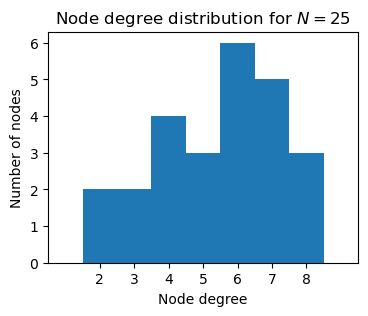

In [180]:
# for example: node degree
N=25; p=.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

degrees = G.degree()
min_degree = min(degrees); max_degree = max(degrees)
bins = np.arange(min_degree, max_degree+2)-.5

ax.hist(degrees, bins=bins)
ax.set_xlim(min_degree-1.5, max_degree+1.5)
ax.set_xticks(bins[:-1]+.5)

ax.set_xlabel("Node degree")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Node degree distribution for $N={N}$")

### _PageRank_

This is a type of eigenvector centrality, and takes into account not only the importance of a single node, but also the importance of the surrounding nodes.

The PageRank values of the nodes in a graph were first defined by Larry Page to quantify the importance of a website. It is mathematically (and recursively) defined as
$$
PR(x_i) = \sum_{x_j \in \mathcal{N}(x_i)} \frac{PR(x_j)}{|\mathcal{N}(x_j)|},
$$
where $\mathcal{N}(x_i)$ represents the neighbourhood of node $x_i$, excluding $x_i$ itself. Note that for a fully-connected network consisting of $N$ nodes, this results in a PageRank of $1/N$ for each node.

One practical advantage of using PageRank is that it is very likely to assign a unique value to each node, even for graphs that are close to regular. One theoretical advantage is that 'the likelikehood to end up on a webpage' or the 'relevance of a webpage' may be an important indicator for how important this node is for the robustness of our entire NA. In other words, this is a good candidate for ordering our TEP.

Text(0.5, 1.0, 'PageRank distribution for $N=1000$\nContains 1000 unique values')

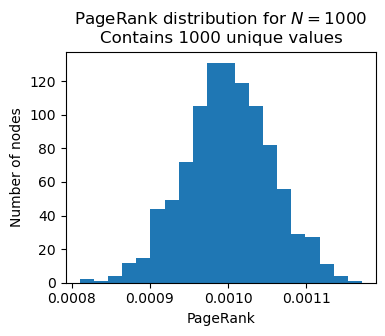

In [181]:
# for example: PageRank
N=1000; p=0.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

PageRank = G.pagerank()
PageRank_unique = len(np.unique(np.array(PageRank)))

bins=20 # None
ax.hist(PageRank,bins=bins)

ax.set_xlabel("PageRank")
ax.set_ylabel("Number of nodes")
ax.set_title(f"PageRank distribution for $N={N}$\nContains {PageRank_unique} unique values")

### _Closeness_

Probably relevant as well: "Closeness centrality finds application in identifying individuals that are in a position to influence the entire network in the fastest way possible." (turing.com)

"Closeness was defined by Bavelas (1950) as the reciprocal of the farness" (Wikipedia), so, normalised over the number of nodes, we get
$$
C(x_i) = (N-1)\left(\sum_{0 \leq j < N}d(x_i, x_j)\right)^{-1},
$$
where $d(x_i, x_j)$ is the shortest path between nodes $x_i$ and $x_j$. A fully-connected graph therefore has a closeness of 1 for each nodes.

Due to the nature of its construction, this measure will not generate unique values for all nodes, which may be an issue when using this for ordering the nodes in a TEP.

A variation on the closeness is the harmonic centrality, which has received less attention in academia. Mathematically, it is simply a matter of changing the order of the sum and inversion operators (and normalising accordingly):
$$
H(x_i) = \frac{1}{N-1}\sum_{0 \leq j < N}\left(\frac{1}{d(x_i, x_j)}\right).
$$

Text(0.5, 1.0, 'harmonic centrality distribution for $N=1000$\nContains 70 unique values')

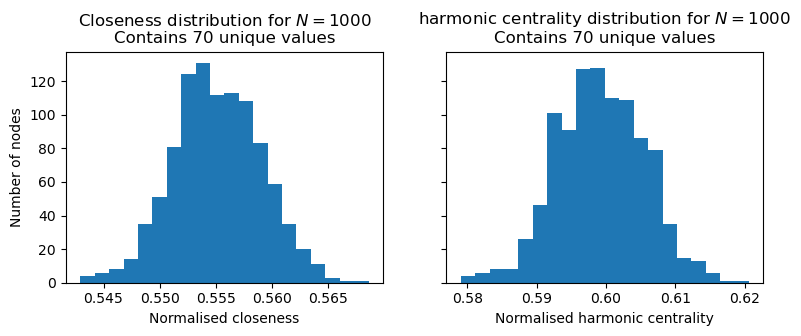

In [183]:
# example: closeness and harmonic centrality
N=1000; p=0.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, axs = plt.subplots(1,2,figsize=(9,3), sharey=True)

closeness = G.closeness(normalized=True)
closeness_unique = len(np.unique(np.array(closeness)))
harmonic = G.harmonic_centrality(normalized=True)
harmonic_unique = len(np.unique(np.array(harmonic)))

bins=20 # None

axs[0].hist(closeness,bins=bins)
axs[1].hist(harmonic,bins=bins)

axs[0].set_xlabel("Normalised closeness")
axs[0].set_ylabel("Number of nodes")
axs[0].set_title(f"Closeness distribution for $N={N}$\nContains {closeness_unique} unique values")

axs[1].set_xlabel("Normalised harmonic centrality")
axs[1].set_title(f"harmonic centrality distribution for $N={N}$\nContains {closeness_unique} unique values")

Text(0.5, 1.0, 'Harmonic centrality vs. Closeness\n$R^2$: 0.9999')

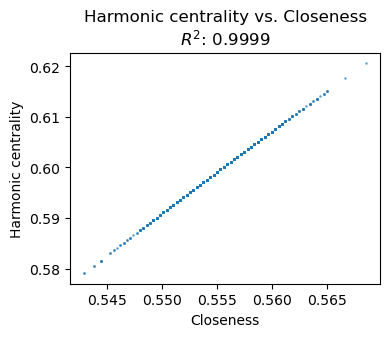

In [184]:
# correlation between harmonic centrality and closeness
fig, ax = plt.subplots(1,1,figsize=(4,3))

PearsonR = np.corrcoef(closeness, harmonic)[0,1]**2

ax.scatter(closeness, harmonic, s=1, alpha=.5)

ax.set_xlabel("Closeness")
ax.set_ylabel("Harmonic centrality")
ax.set_title(f"Harmonic centrality vs. Closeness\n$R^2$: {round(PearsonR,5)}")

In other words, we can choose the measure that we like most, as they are virtually identical.

### _Betweenness_

"Measure for the number of shortest paths that pass through a node. Nodes with high betweenness centrality are critical for information flow. Their stability can enhance the overall robustness of the network." (ChatGPT)

Mathematically, betweenness is calculated as follows:
$$
g(x_i) = \sum_{j\neq i}\sum_{k\neq i}\frac{\sigma_{jk}(x_i)}{\sigma_{jk}},
$$
where $\sigma_{jk}$ is the _total_ number of shortest paths from node $x_j$ to $x_k$, and $\sigma_{jk}(x_i)$ is the number of those paths that pass through node $x_i$. Note that the sum only goes over nodes that are not identical to $x_i$, so the shortest paths can never end in $x_i$.

Interestingly, betweenness is (typically) a unique value per node, so ordering would be straightforward.

Text(0.5, 1.0, 'Betweenness distribution for $N=1000$\nContains 1000 unique values')

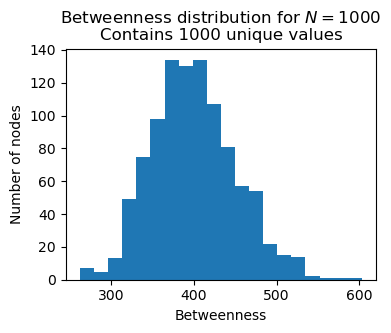

In [185]:
# example: betweenness
N=1000; p=0.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

betweenness = G.betweenness(directed=False)
betweenness_unique = len(np.unique(np.array(betweenness)))

bins=20 # None
ax.hist(betweenness,bins=bins)

ax.set_xlabel("Betweenness")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Betweenness distribution for $N={N}$\nContains {betweenness_unique} unique values")

Considering that betweenness and PageRank both generate unique values per node, both are interesting for finding a unique node ordering. Let's inspect whether these quantities are related to each other in a simple scatter plot.

Text(0.5, 1.0, 'Betweenness vs. PageRank. $R^2$: 0.99')

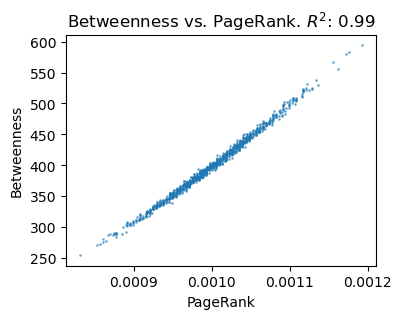

In [186]:
# comparing betweenness and PageRank
N=1000; p=0.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, ax = plt.subplots(1,1,figsize=(4,3))

PageRank = G.pagerank()
betweenness = G.betweenness(directed=False)
PearsonR = np.corrcoef(PageRank, betweenness)[0,1]**2

ax.scatter(PageRank, betweenness, s=1, alpha=.5)

ax.set_xlabel("PageRank")
ax.set_ylabel("Betweenness")
ax.set_title(f"Betweenness vs. PageRank. $R^2$: {round(PearsonR,2)}")

Clearly, these are highly correlated.

### _Clustering coefficient_

Also known as transitivity.

"A measure of the degree to which nodes in a graph tend to cluster together.
High clustering can enhance local robustness, as tightly-knit clusters may stabilize each other." (ChatGPT)

This measure is particularly relevant for Watts-Strogatz graphs (and they came up with it). The centrality of node $x_i$ is defined as (Wikipedia)
$$
C_i = \frac{2|\{e_{jk} : x_j, x_k \in \mathcal{N}(x_i), e_{jk} \in E\}|}{|\mathcal{N}(x_i)||\mathcal{N}(x_i)-1|},
$$
where $\mathcal{N}(x_i)$ is the neighbourhood of node $x_i$ excluding node $x_i$ itself (more simply put: $|\mathcal{x_i}|$ is simply the degree of node $x_i$). This is identical to saying that
$$
C_i = \frac{\lambda_G(x_i)}{\tau_G(x_i)},
$$
where $\lambda_G(x_i)$ is the number of triangles on $x_i$, and $\tau_G(x_i)$ is the number of triples on $x_i$. Note that, because $\tau_G(x_i) \geq \lambda_G(x_i)$, $C_i$ is always between 0 and 1.

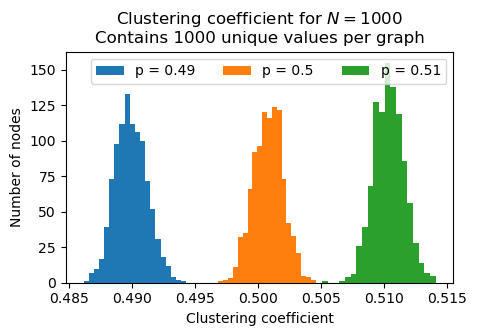

In [187]:
# example: clustering
N=1000
ps=[0.49, 0.5, 0.51]
Gs = []

for p in ps:
    G = ig.Graph.Erdos_Renyi(n=N, p=p)
    Gs.append(G)

fig, ax = plt.subplots(1,1,figsize=(5,3))
bins=20 # None

for p, G in zip(ps,Gs):
    clustering = G.transitivity_local_undirected()
    clustering_unique = len(np.unique(np.array(clustering)))
    ax.hist(clustering,bins=bins, label=f"p = {p}")

ax.set_xlabel("Clustering coefficient")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Clustering coefficient for $N={N}$\nContains {betweenness_unique} unique values per graph")
plt.legend(ncols=3)

Note that a higher rewiring probability (parameter `p`) generates higher clustering coefficients. Generally, the higher the number of nodes $N$, the more clearly the clustering coefficient distributions will be separated. In addition, note that again all clustering values are unique, which is desired for the ordering of our nodes in the TEP.

### _Similarity measures_

We can compare a node with all other nodes and give a score which quantifies how 'similar' they are, with some well-defined notion of similarity. This results in a similarity matrix $\Sigma$ with elements $\Sigma_{ij}$ for $0 \leq i,j < N$. The `igraph` package provides three variations:

1. _Jaccard similarity_: The Jaccard similarity coefficient of two vertices is the number of their common neighbors divided by the number of vertices that are adjacent to at least one of them.

2. _Dice similarity_: The Dice similarity coefficient of two vertices is twice the number of their common neighbors divided by the sum of their degrees. This
coefficient is very similar to the Jaccard coefficient, but usually gives higher similarities than its counterpart.

3. _Inverse log-weighted similarity_: Each vertex is assigned a weight which is 1 / log(degree). The log-weighted similarity of two vertices is the sum of the weights of their common neighbors.

Clearly, these measures generate a _vector_ per node, which is perhaps not ideal for ordering the nodes. But they are briefly investigated below regardless.

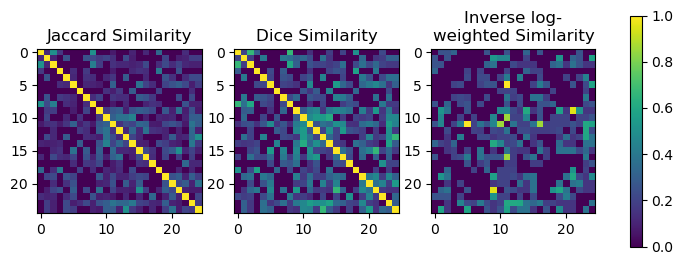

In [188]:
# for example: similarity measures
import igraph as ig
import matplotlib.pyplot as plt

N=25; p=.2
G = ig.Graph.Erdos_Renyi(n=N, p=p)

fig, axs = plt.subplots(1,3,figsize=(9,3))

jacc_sim = G.similarity_jaccard()
dice_sim = G.similarity_dice()
inverse_log = G.similarity_inverse_log_weighted()

im=axs[0].imshow(jacc_sim)
axs[1].imshow(dice_sim)
axs[2].imshow(inverse_log)

axs[0].set_title(f"Jaccard Similarity")
axs[1].set_title(f"Dice Similarity")
axs[2].set_title(f"Inverse log-\nweighted Similarity")

fig.colorbar(im, ax=axs.ravel().tolist())

## 2.4 - Assessing robustness by means of the Lyapunov spectrum

### _Configuration space interpretation_

In [ ]:
### defined by ratio of two subsequent values.

### _Tangent space interpretation_

From the Jacobian, we define the Lyapunov spectrum:
$$
\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln\Lambda_i^t,
$$
where the $\Lambda_i^t$ are the eigenvalues associated to the equation
$$
\langle \mathbf{Y}^t \vec{x}_i, \mathbf{Y}^t \vec{x}_i \rangle = (\Lambda^t_i)^2 \langle \vec{x}_i, \vec{x}_i \rangle.
$$
Therefore we need to calculate the eigenvalues of the matrix $\mathbf{Y}^t \left(\mathbf{Y}^t\right)^\text{T}$

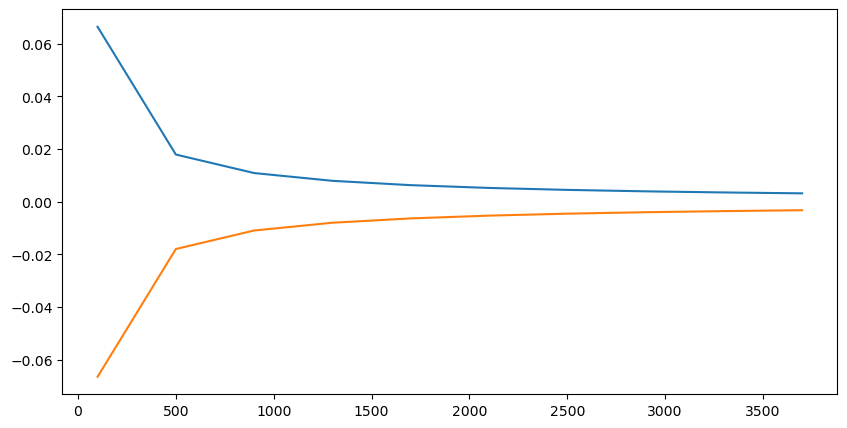

In [261]:
def calculate_Yt(graph, model, states, T):
    N = len(states)
    Yt = np.diag(np.ones(N).astype(int))
    for _ in range(T):
        J, states = jacobian(graph, model, states, return_next=True)
        Yt = np.matmul(J, Yt)
    return Yt


def lyapunov_spectrum(Yt, T):
    Gamma = np.matmul(Yt, Yt.T)
    Lambdas = np.linalg.eigvals(Gamma)
    lambdas = np.log(Lambdas)/(2*T)
    return lambdas

states = np.random.randint(2, size=N)
T_range = np.array(range(100, 4000, 400))
lambdas_mins = []
lambdas_maxs = []

for T in T_range:
    print(f"Working on T={T}", end='\r')
    Yt = calculate_Yt(G, model, states, T)
    lambdas = lyapunov_spectrum(Yt, T)
    lambdas = lambdas[np.isfinite(lambdas)]
    lambdas_min = np.min(lambdas)
    lambdas_max = np.max(lambdas)
    lambdas_mins += [lambdas_min]
    lambdas_maxs += [lambdas_max]

fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(T_range, lambdas_maxs, label=f"maxima (ends at {lambdas_max})")
ax.plot(T_range, lambdas_mins, label=f"finite minima (ends at {lambdas_min})")

## 2.5 - Pipeline for computational experiments

(this is largely a transcription of the method expressed in the script, src and tests directories)

In [1]:
np.log(4)

NameError: name 'np' is not defined

<hr>

# 3 - Results

## 3.1 - First experiments with generating and ordering defect TEPs

### _load a particular network and inspect some properties_

In [139]:
PATH = 'data/graphs/'
network_name = 'network_0000'

# Open the file and read its contents
with open(PATH+network_name+'.txt', 'r') as file:
    lines = file.readlines()

# Remove trailing newline characters from each line
lines = [line.strip() for line in lines]

N_nodes = int(lines[0].split(' ')[0])
N_edges = int(lines[0].split(' ')[1])

edges_raw = np.array(lines[6:])
edges = []
for i, edge_raw in enumerate(edges_raw):
    e_i = int(edge_raw.split(' ')[0])
    e_j = int(edge_raw.split(' ')[1])
    edges += [(e_i, e_j)]

G = ig.Graph()
G.add_vertices(range(N_nodes))
G.add_edges(edges)


C:\Users\mrollier\AppData\Local\Temp\ipykernel_3240\1698006705.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


Text(0.5, 0.98, 'Various node properties.\n(Current node order based on Barabasi-Albert construction algorithm.)')

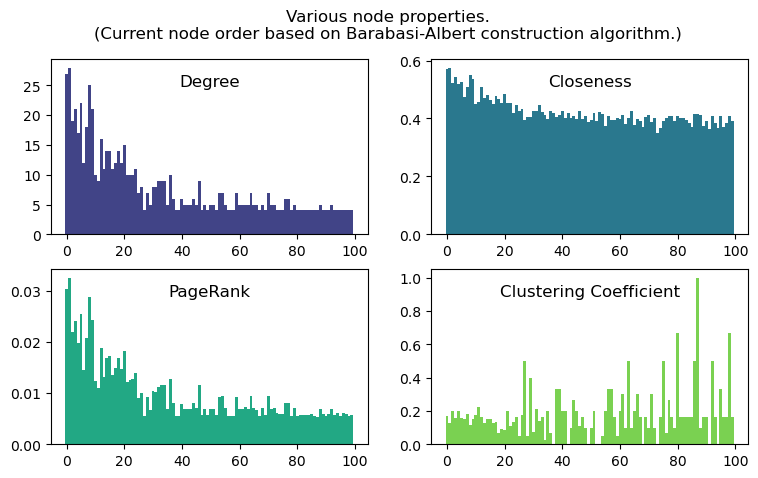

In [140]:
# show properties per node, in the order they have been created by default
from matplotlib import cm
fig, axs = plt.subplots(2,2,figsize=(9,5))

degrees = G.degree()
closeness = G.closeness(normalized=True)
pagerank= G.pagerank()
clustering = G.transitivity_local_undirected()

cmap = cm.get_cmap('viridis')
colors = [cmap(.2), cmap(.4), cmap(.6), cmap(.8)]

axs[0,0].bar(range(N_nodes), degrees, width=1, color=colors[0])
axs[0,1].bar(range(N_nodes), closeness, width=1, color=colors[1])
axs[1,0].bar(range(N_nodes), pagerank, width=1, color=colors[2])
axs[1,1].bar(range(N_nodes), clustering, width=1, color=colors[3])

axs[0,0].set_title("Degree", y=.8)
axs[0,1].set_title("Closeness", y=.8)
axs[1,0].set_title("PageRank", y=.8)
axs[1,1].set_title("Clustering Coefficient", y=.8)

fig.suptitle("Various node properties.\n(Current node order based on Barabasi-Albert construction algorithm.)")

Clearly the default order of the nodes, which is a result of how the Barabasi-Albert graph has been constructed, is correlated to the four selected properties above. That is to say: there is some merit in using the default order as well.

Now let's see what these distributions look like when we order them.

C:\Users\mrollier\AppData\Local\Temp\ipykernel_3240\1711777168.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


Text(0.5, 0.98, 'Various node properties (nodes ordered based on the measure value).')

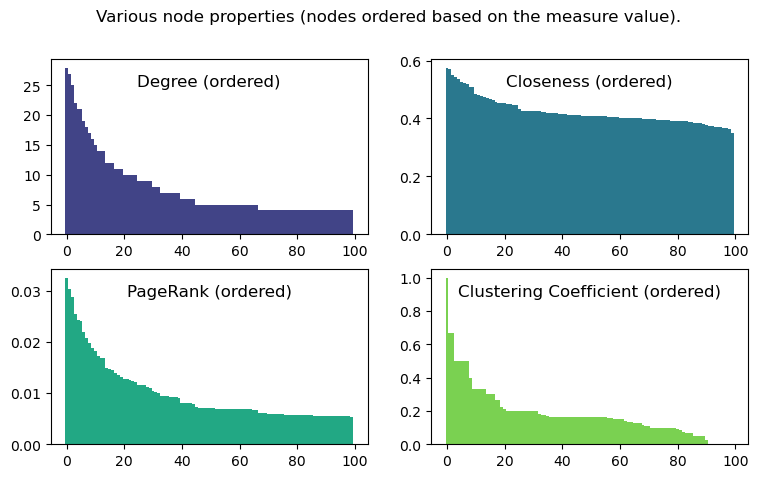

In [141]:
# show properties per node, in the order they have been created by default
from matplotlib import cm
fig, axs = plt.subplots(2,2,figsize=(9,5))

degrees = G.degree()
closeness = G.closeness(normalized=True)
pagerank= G.pagerank()
clustering = G.transitivity_local_undirected()

cmap = cm.get_cmap('viridis')
colors = [cmap(.2), cmap(.4), cmap(.6), cmap(.8)]

axs[0,0].bar(range(N_nodes), np.sort(degrees)[::-1], width=1, color=colors[0])
axs[0,1].bar(range(N_nodes), np.sort(closeness)[::-1], width=1, color=colors[1])
axs[1,0].bar(range(N_nodes), np.sort(pagerank)[::-1], width=1, color=colors[2])
axs[1,1].bar(range(N_nodes), np.sort(clustering)[::-1], width=1, color=colors[3])

axs[0,0].set_title("Degree (ordered)", y=.8)
axs[0,1].set_title("Closeness (ordered)", y=.8)
axs[1,0].set_title("PageRank (ordered)", y=.8)
axs[1,1].set_title("Clustering Coefficient (ordered)", y=.8)

fig.suptitle("Various node properties (nodes ordered based on the measure value).")

### _Show ordered defect TEPs_

First load some of the simulated TEPs, and find the associated defect TEP

Text(0, 0.5, '$\\leftarrow$ Time')

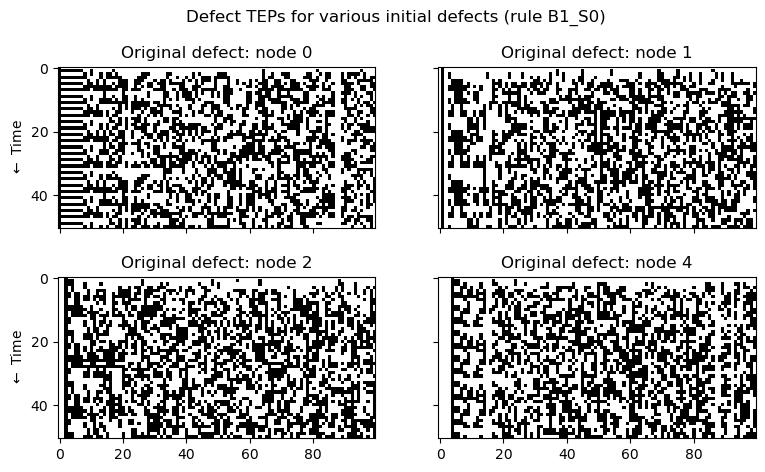

In [206]:
from src.simulation import load_tensor
RES = 2
RULE = 'B1_S0'
PATH = f"data/teps/R={RES}/{RULE}/"

tep = load_tensor(PATH, network_name)
teps_defect = []
defect_nodes = [0, 1, 2, 4]

for defect_node in defect_nodes:
    tep_original = tep[0,0,:,:]
    tep_disturbed = tep[0,defect_node+1,:,:]
    tep_defect = abs(tep_original-tep_disturbed)
    teps_defect += [tep_defect]

# default defect TEP for various affected nodes
fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True, sharey=True)

axs[0,0].imshow(teps_defect[0], cmap='Greys')
axs[0,1].imshow(teps_defect[1], cmap='Greys')
axs[1,0].imshow(teps_defect[2], cmap='Greys')
axs[1,1].imshow(teps_defect[3], cmap='Greys')

axs[0,0].set_title(f"Original defect: node {defect_nodes[0]}")
axs[0,1].set_title(f"Original defect: node {defect_nodes[1]}")
axs[1,0].set_title(f"Original defect: node {defect_nodes[2]}")
axs[1,1].set_title(f"Original defect: node {defect_nodes[3]}")

fig.suptitle(f'Defect TEPs for various initial defects (rule {RULE})')
axs[0,0].set_ylabel(f'$\leftarrow$ Time')
axs[1,0].set_ylabel(f'$\leftarrow$ Time')
# plt.xlabel(f'Nodes (default order)')

Next, find representations in different orderings, based on the centrality measures.

Text(0, 0.5, '$\\leftarrow$ Time')

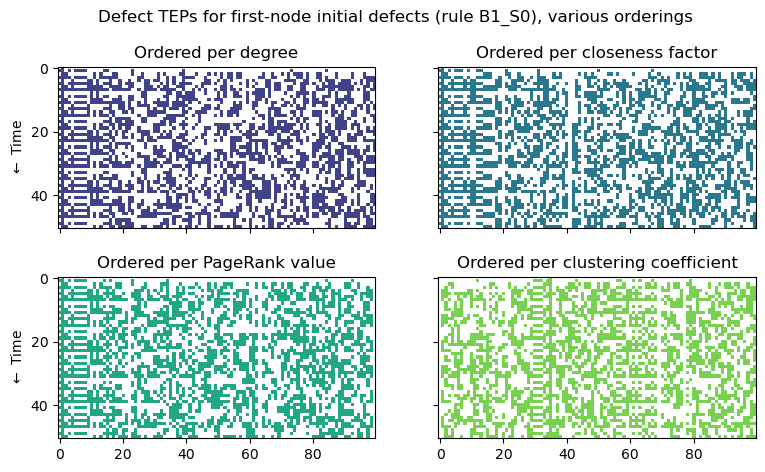

In [207]:
degree_indices = np.argsort(degrees)[::-1]
closeness_indices = np.argsort(closeness)[::-1]
pagerank_indices = np.argsort(pagerank)[::-1]
clustering_indices = np.argsort(clustering)[::-1]

default_node = 0

tep_ordered_degree = np.array(teps_defect[default_node])[:,degree_indices]
tep_ordered_closeness = np.array(teps_defect[default_node])[:,closeness_indices]
tep_ordered_pagerank = np.array(teps_defect[default_node])[:,pagerank_indices]
tep_ordered_clustering = np.array(teps_defect[default_node])[:,clustering_indices]

from matplotlib.colors import LinearSegmentedColormap
LinearSegmentedColormap.from_list

cmap_degree = LinearSegmentedColormap.from_list('cmap_degree', [(1,1,1,1),colors[0]], N=2)
cmap_closeness = LinearSegmentedColormap.from_list('cmap_closeness', [(1,1,1,1),colors[1]], N=2)
cmap_pagerank = LinearSegmentedColormap.from_list('cmap_pagerank', [(1,1,1,1),colors[2]], N=2)
cmap_clustering = LinearSegmentedColormap.from_list('cmap_clustering', [(1,1,1,1),colors[3]], N=2)

fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True, sharey=True)

axs[0,0].imshow(tep_ordered_degree, cmap=cmap_degree)
axs[0,1].imshow(tep_ordered_closeness, cmap=cmap_closeness)
axs[1,0].imshow(tep_ordered_pagerank, cmap=cmap_pagerank)
axs[1,1].imshow(tep_ordered_clustering, cmap=cmap_clustering)

axs[0,0].set_title("Ordered per degree")
axs[0,1].set_title("Ordered per closeness factor")
axs[1,0].set_title("Ordered per PageRank value")
axs[1,1].set_title("Ordered per clustering coefficient")

# default defect TEP for various affected nodes
fig.suptitle(f'Defect TEPs for first-node initial defects (rule {RULE}), various orderings')

axs[0,0].set_ylabel(f'$\leftarrow$ Time')
axs[1,0].set_ylabel(f'$\leftarrow$ Time')
# plt.xlabel(f'Nodes (default order)')

This, of course, is still not really insightful.

In a next step, we can try to extract a single property from the entire defect TEP (such as the radius of the defect subgraph), and plot this in function of the perturbed node. The order of the nodes (i.e. the convention as to what determines the 'second' node to be second, for example) may then demonstrate a particular relationship between a centrality measure and the NA robustness. This, in turn, can highlight which nodes play an important role in the NA and which may be altered without significant changes to the overall dynamics.